In [1]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

from IPython.display import Markdown

from pathlib import Path
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.notebooks.eda import *
from birdclef_2026_ml.processing.audio_utils import load_train_audio, load_soundscape_audio
#from birdclef_2026_ml.configs import FeatureConfig
#from birdclef_2026_ml.audio.silence_detect import *
#from birdclef_2026_ml.audio import apply_spectral_gating
from birdclef_2026_ml.paths import load_project_paths

init_notebook()

In [6]:
feature_cfg = FeatureConfig()
train = pd.read_parquet(PATHS["proc_train"])
soundscapes = pd.read_parquet(PATHS["proc_soundscapes"])
taxonomy = pd.read_csv(PATHS["taxonomy"])
soundscapes

,filename,start,end,primary_label,primary_label_list,datetime,start_sec,end_sec,class_name_list,primary_label_int_list,class_name_int_list
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,0.0,5.0,"[Amphibia, Amphibia, Amphibia, Amphibia, Amphi...","[8.0, 15.0, 21.0, 57.0, 63.0]",[0.0]
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,5.0,10.0,"[Amphibia, Amphibia, Amphibia, Amphibia, Amphi...","[8.0, 15.0, 21.0, 57.0, 63.0]",[0.0]
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,10.0,15.0,"[Amphibia, Amphibia, Amphibia, Amphibia, Amphi...","[8.0, 15.0, 21.0, 57.0, 63.0]",[0.0]
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,15.0,20.0,"[Amphibia, Amphibia, Amphibia, Amphibia, Amphi...","[8.0, 15.0, 21.0, 57.0, 63.0]",[0.0]
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,20.0,25.0,"[Amphibia, Amphibia, Amphibia, Amphibia, Amphi...","[8.0, 15.0, 21.0, 57.0, 63.0]",[0.0]
...,...,...,...,...,...,...,...,...,...,...,...
734,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380,"[555146, 65380]",2022-02-19 20:00:00,35.0,40.0,"[Amphibia, Amphibia]","[60.0, 63.0]",[0.0]
735,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146,"[517063, 555146]",2022-02-19 20:00:00,40.0,45.0,"[Amphibia, Amphibia]","[57.0, 60.0]",[0.0]
736,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146,"[517063, 555146]",2022-02-19 20:00:00,45.0,50.0,"[Amphibia, Amphibia]","[57.0, 60.0]",[0.0]
737,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971,"[517063, 555146, 66971]",2022-02-19 20:00:00,50.0,55.0,"[Amphibia, Amphibia, Amphibia]","[57.0, 60.0, 64.0]",[0.0]


### Spectral shape
- spectral centroid (mean, std)
- spectral bandwidth (mean, std)
- spectral rolloff (mean, std)
- spectral flatness (mean, std)
- spectral contrast (mean, std)

Why:
* separates taxa well:
    * insects → high centroid, high flatness
    * amphibians/mammals → lower centroid

In [ ]:
train_slice = train.groupby('class_name', sort=False, as_index=False).first()
# extra_titles = (
#     train_slice["common_name"].astype(str) + "_"
#     + train_slice["class_name"].astype(str) + " "
# ).tolist()

,class_name,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,inat_taxon_id,author,license,rating,url,filename,collection,primary_label_int,class_name_int,duration
0,Insecta,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,0.0,2.0,18.024000
1,Reptilia,116570,[],[],-27.7287,-56.8599,Caiman yacare,Southern Spectacled Caiman,116570,None,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1460166....,116570/iNat1460166.ogg,iNat,1.0,4.0,7.862844
2,Amphibia,1176823,[],[],-36.6130,-64.3261,Leptodactylus luctator,Wrestler Frog,1176823,Nadia Naab,cc-by-nc,5.0,https://static.inaturalist.org/sounds/936019.m...,1176823/iNat936019.ogg,iNat,2.0,0.0,13.418688
3,Mammalia,209233,[],[],49.2473,-107.7249,Equus caballus,Feral Horse,209233,Sam,cc-by-nc,5.0,https://static.inaturalist.org/sounds/864998.m...,209233/iNat864998.ogg,iNat,5.0,3.0,17.182781
4,Aves,ashgre1,[],"[call, song]",-23.7629,-53.8803,Hylophilus pectoralis,Ashy-headed Greenlet,17431,Luiz C. Silva,by-nc-sa,5.0,https://xeno-canto.org/684562/download,ashgre1/XC684562.ogg,XC,72.0,1.0,30.876000


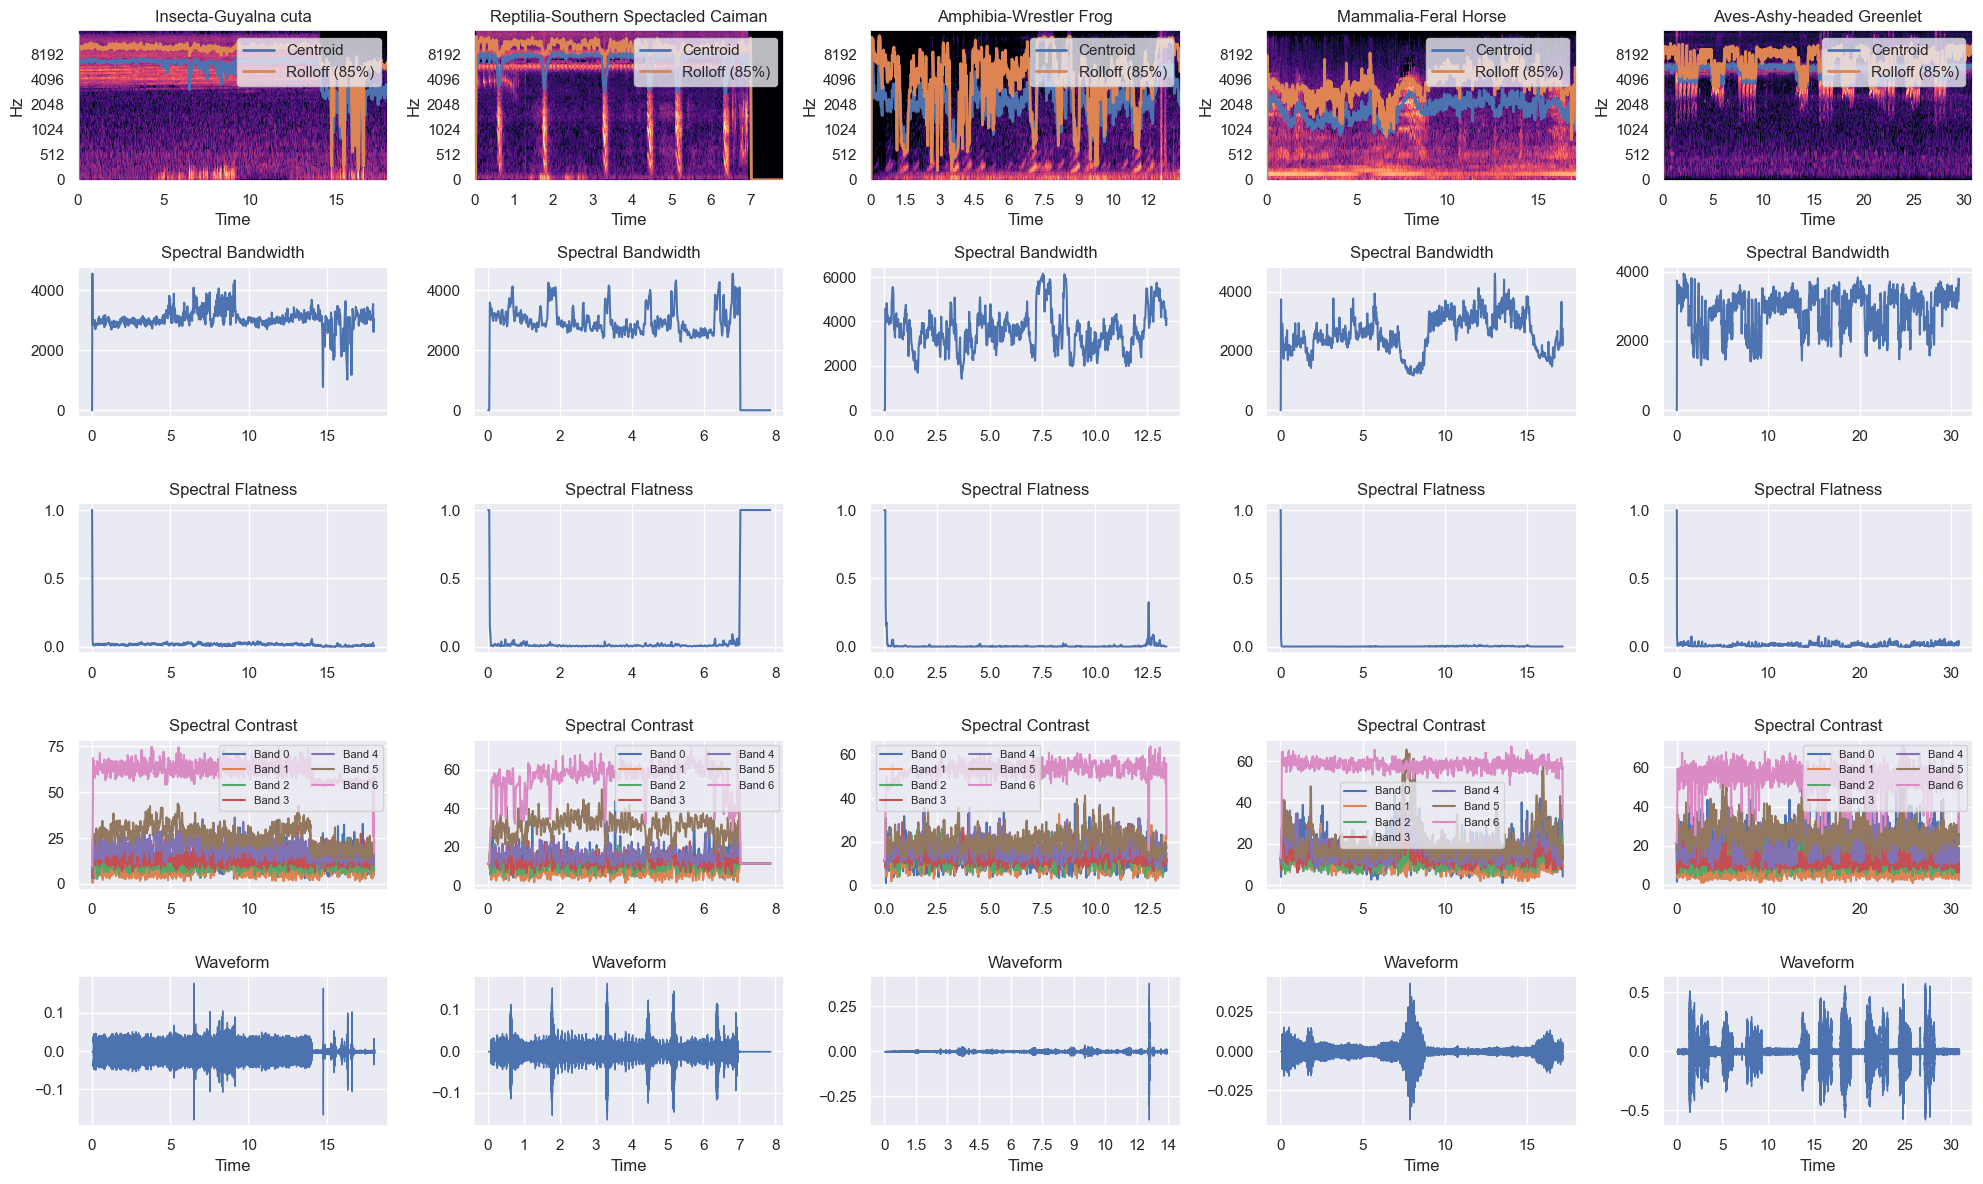

In [13]:
fig, axes = plt.subplots(5, 5, figsize=(20, 12))
train_slice = train.groupby('class_name', sort=False, as_index=False).first()
titles = train_slice["class_name"] + '-' + train_slice["common_name"]

for i, filename,  in enumerate(train_slice["filename"]):
    path = PATHS["train_audio_spectral_gating_dir"] / filename
    plot_spectral_diagnostics(path, feature_cfg, axes=axes[:, i], title=titles[i])
plt.tight_layout()

### Temporal dynamic
* RMS energy (mean, std)
* Zero-crossing rate (mean, std)
* Envelope variance
* Peak density (simple peak count / sec)
* Energy modulation (std of frame energy)

Why:

* insects: high ZCR, steady energy
* birds: bursty → higher modulation / peak density
* amphibians: periodic structure

### Features after spectral gating
Features that capture SNR are less important, focus on features that capture structure

1. Profiles + cos similarity with L2 normalization
2. Spectral entropy 
- low entropy -> tonal species (frogs, birds)
- high entropy -> insects or complex multi-source scenes
3. High-frequency energy ratio (improves insect vs bird separation)
4. Spectral centroid/rolloff/bandwidth (become redundant with profiles/entropy)
5. Spectral constrast (not a primary feature, constrast increases globally due to gating)
6. RMS energy (HIGH)
7. Zero-crossing rate (tonal vs noisy structure)
8. Burstiness index (HIGH VALUE)
Very strong for:
- birds (bursty)
- amphibians (periodic bursts)
9. Peak density (HIGH VALUE)
10. Energy modulation (VERY HIGH VALUE)
11. Spectral flux (VERY HIGH VALUE)

⸻

What becomes LESS important after spectral gating

You can reduce weight or even drop:

* ZCR (partially redundant now)
* flatness (overlaps with entropy)
* heavy noise-robust descriptors
* overly complex redundancy-based features

### Profiles

In [7]:
run_name = "run_2"
profiles = np.load(PATHS["models"] / "profiles" / "species_profiles.npy")
profiles_ids = np.load(PATHS["models"] / "profiles" / "species_profile_ids.npy")

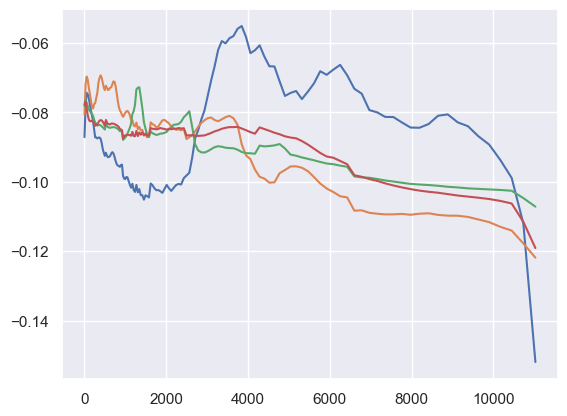

In [31]:
mel_freq = librosa.mel_frequencies(128)
plt.plot(mel_freq, profiles[0, :] / np.linalg.norm(profiles[0, :]))
plt.plot(mel_freq, profiles[10, :]  / np.linalg.norm(profiles[10, :]))
plt.plot(mel_freq, profiles[50, :]  / np.linalg.norm(profiles[50, :]))
plt.plot(mel_freq, profiles[-1, :]  / np.linalg.norm(profiles[-1, :]))

### Species type (`class_name`) and frequencies bands

In [17]:
def compute_species_profile(y, cfg, n_mels=128):
    mel = librosa.feature.melspectrogram(y=y, sr=cfg.sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=1.0) 
    species_profile = np.median(mel_db, axis=1)

    dominant = np.argmax(mel_db, axis=0)
    hist = np.bincount(dominant, minlength=mel_db.shape[0])
    hist = hist / hist.sum() # normalize to get probability distribution

    return species_profile, hist


def compute_species_profile_for_group(
    group,
    full_df,
    cfg,
    n_mels=128,
    max_files_per_species=100,
    filename_col="filename",
):
    row_positions = group["row_pos"].head(max_files_per_species).astype(int).tolist()
    profiles = []
    hists = []

    for pos in row_positions:
        y, _ = load_train_audio(full_df, idx=pos, filename_col=filename_col, sr=cfg.sr)
        profile, hist = compute_species_profile(y, cfg, n_mels=n_mels)
        profiles.append(profile)
        hists.append(hist)

    return pd.Series([np.median(np.vstack(profiles), axis=0), np.mean(np.vstack(hists), axis=0)])


In [18]:
train_pos = train.reset_index(drop=True).reset_index(names="row_pos")
species_profiles = (
    train_pos.groupby("class_name")
    .apply(
        compute_species_profile_for_group,
        full_df=train,
        cfg=cfg,
        n_mels=128,
        max_files_per_species=100,
    )
    .rename(columns={0: "species_profile", 1: "species_hist"})
    .reset_index()
)

species_profiles["mel_frequencies"] = species_profiles["species_profile"].apply(
    lambda species_profile: librosa.mel_frequencies(
        n_mels=len(species_profile),
        fmin=0,
        fmax=cfg.sr // 2,
    )
)

In [19]:
plot_df = species_profiles[["class_name", "mel_frequencies", "species_profile", "species_hist"]].copy()
plot_df["mel_frequencies"] = plot_df["mel_frequencies"].apply(lambda x: np.asarray(x).tolist())
plot_df["species_profile"] = plot_df["species_profile"].apply(lambda x: np.asarray(x).tolist())
plot_df["species_hist"] = plot_df["species_hist"].apply(lambda x: np.asarray(x).tolist())

plot_df = plot_df.explode(["mel_frequencies", "species_profile", "species_hist"], ignore_index=True)
plot_df["mel_frequencies"] = plot_df["mel_frequencies"].astype(float)
plot_df["species_profile"] = plot_df["species_profile"].astype(float)
plot_df["species_hist"] = plot_df["species_hist"].astype(float)

##### Energy profile for each species type

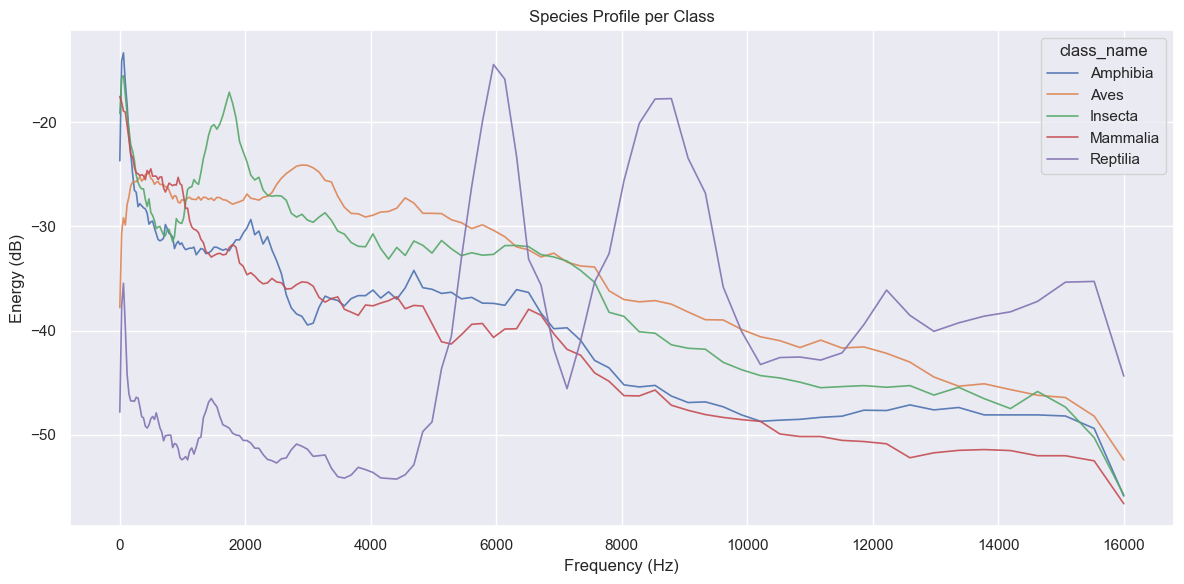

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="mel_frequencies",
    y="species_profile",
    hue="class_name",
    estimator=None,
    sort=False,
    linewidth=1.2,
    alpha=0.9,
    legend="brief",
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Energy (dB)")
plt.title("Species Profile per Class")
plt.tight_layout()

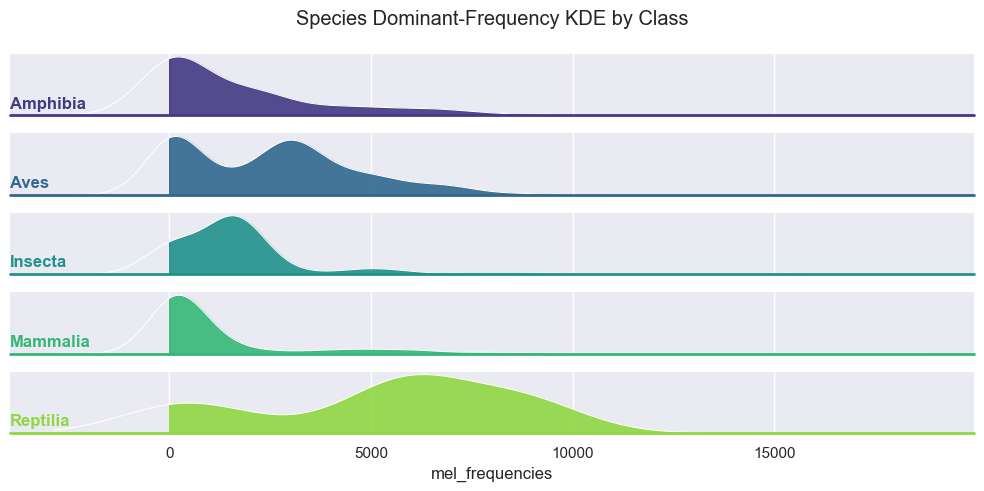

In [53]:
g = sns.FacetGrid(
    plot_df,
    row="class_name",
    hue="class_name",
    aspect=10,
    height=1,
    palette="viridis",
    sharex=True,
    sharey=False,
 )

g.map_dataframe(
    sns.kdeplot,
    x="mel_frequencies",
    weights="species_hist",
    bw_adjust=0.6,
    fill=True,
    alpha=0.9,
    linewidth=1.0,
    common_norm=False,
    clip=(plot_df["mel_frequencies"].min(), plot_df["mel_frequencies"].max()),
)

g.map_dataframe(
    sns.kdeplot,
    x="mel_frequencies",
    weights="species_hist",
    bw_adjust=0.6,
    color="white",
    linewidth=0.8,
    common_norm=False,
 )

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "mel_frequencies")

# Set the subplots to overlap
#g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.figure.suptitle("Species Dominant-Frequency KDE by Class")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.tight_layout()

### Profiles per `primary_label`

In [2]:
train_pos = train.reset_index(drop=True).reset_index(names="row_pos")
species_profiles = (
    train_pos.groupby("primary_label")
    .apply(
        compute_species_profile_for_group,
        full_df=train,
        cfg=cfg,
        n_mels=128,
        max_files_per_species=100,
    )
    .rename(columns={0: "species_profile", 1: "species_hist"})
    .reset_index()
)

species_profiles["mel_frequencies"] = species_profiles["species_profile"].apply(
    lambda species_profile: librosa.mel_frequencies(
        n_mels=len(species_profile),
        fmin=0,
        fmax=cfg.sr // 2,
    )
)

NameError: name 'train' is not defined

In [317]:
species_profiles["mel_frequencies"] = species_profiles["mel_frequencies"].apply(lambda x: np.asarray(x).tolist())
species_profiles["species_profile"] = species_profiles["species_profile"].apply(lambda x: np.asarray(x).tolist())
species_profiles["species_hist"] = species_profiles["species_hist"].apply(lambda x: np.asarray(x).tolist())

species_profiles = species_profiles.explode(["mel_frequencies", "species_profile", "species_hist"], ignore_index=True)
species_profiles["mel_frequencies"] = species_profiles["mel_frequencies"].astype(float)
species_profiles["species_profile"] = species_profiles["species_profile"].astype(float)
species_profiles["species_hist"] = species_profiles["species_hist"].astype(float)

NameError: name 'species_profiles' is not defined

In [7]:
fig = plot_soundscape_window_with_profiles(soundscapes,
                                           species_profiles,
                                           "BC2026_Train_0039_S22_20211231_201500.ogg",
                                           start=0,
                                           end=5)

NameError: name 'species_profiles' is not defined

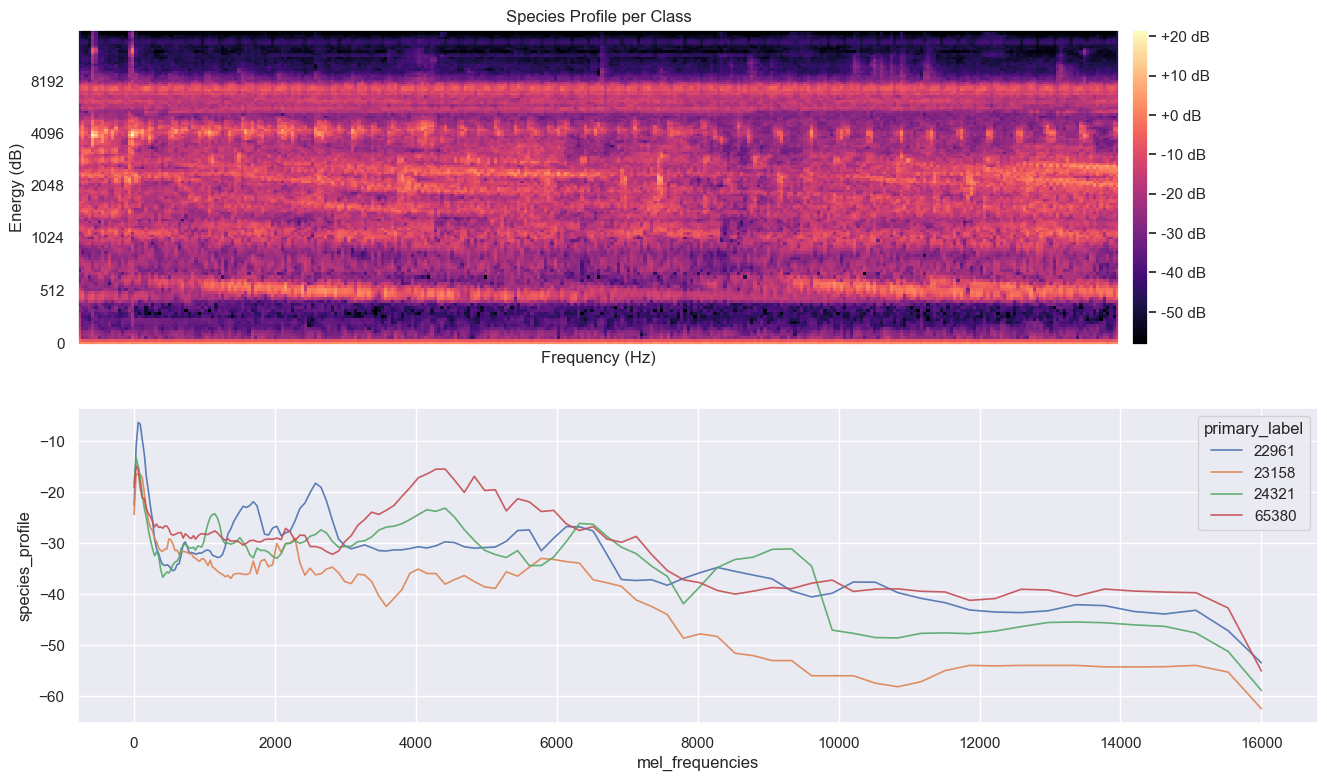

In [45]:
fig = plot_soundscape_window_with_profiles(soundscapes,
                                           species_profiles,
                                           "BC2026_Train_0039_S22_20211231_201500.ogg",
                                           start=10,
                                           end=15)

In [ ]:
S = librosa.feature.melspectrogram(y=y_clean, sr=cfg.sr, n_mels=cfg.n_mels)
S_db = librosa.power_to_db(S, ref=np.max)

profile = robust_time_pooling(S_db, method="trimmed_mean", percentile=80)
profile

array([-68.692566, -59.93035 , -59.753   , -62.415367, -65.26448 ,
       -67.29548 , -69.81859 , -71.02966 , -72.41204 , -73.715164,
       -74.80944 , -75.62503 , -75.994644, -75.71007 , -75.79213 ,
       -76.10332 , -76.24658 , -76.30893 , -76.0889  , -75.846634,
       -75.95253 , -75.88803 , -75.896774, -76.05248 , -75.920395,
       -75.78378 , -75.8163  , -75.5444  , -75.28516 , -75.486374,
       -75.441895, -74.27405 , -72.15958 , -70.97748 , -71.56196 ,
       -70.84695 , -65.94639 , -58.219692, -52.23929 , -52.76567 ,
       -58.54389 , -62.11869 , -61.484234, -58.553074, -56.63938 ,
       -56.416523, -54.744972, -52.123314, -52.12873 , -51.871567,
       -48.756744, -40.64722 , -33.77234 , -30.48206 , -30.605362,
       -30.66833 , -36.822777, -47.462204, -50.091103, -49.43315 ,
       -50.362534, -51.442738, -55.288773, -60.66712 , -59.777756,
       -58.488342, -59.701958, -60.82437 , -60.99656 , -59.60785 ,
       -59.479942, -60.256836, -60.78306 , -61.430416, -62.237

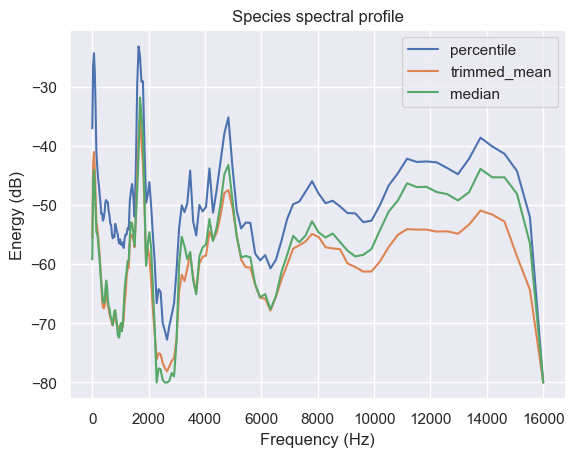

In [310]:
S = librosa.feature.melspectrogram(y=y_clean, sr=cfg.sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)


mel_frequencies = librosa.mel_frequencies(n_mels=128, fmin=0, fmax=cfg.sr/2)
plt.plot(mel_frequencies, robust_time_pooling(S_db, method="percentile", percentile=80), label="percentile")
plt.plot(mel_frequencies, robust_time_pooling(S_db, method="trimmed_mean", percentile=80), label="trimmed_mean")
plt.plot(mel_frequencies, robust_time_pooling(S_db, method="median", percentile=80), label="median")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Energy (dB)")
plt.title("Species spectral profile")
plt.legend()

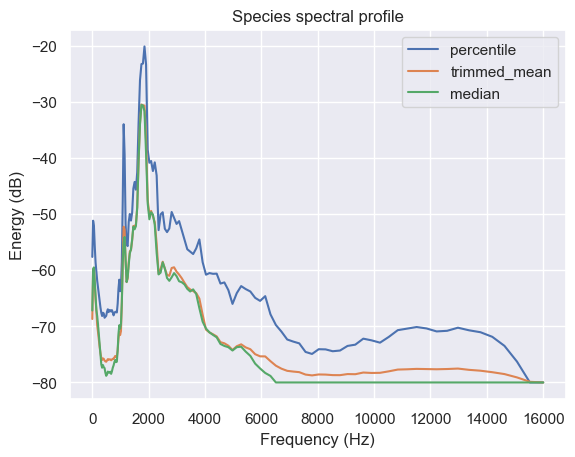

In [314]:
S = librosa.feature.melspectrogram(y=y_clean, sr=cfg.sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)


mel_frequencies = librosa.mel_frequencies(n_mels=128, fmin=0, fmax=cfg.sr/2)
plt.plot(mel_frequencies, robust_time_pooling(S_db, method="percentile", percentile=80), label="percentile")
plt.plot(mel_frequencies, robust_time_pooling(S_db, method="trimmed_mean", percentile=80), label="trimmed_mean")
plt.plot(mel_frequencies, robust_time_pooling(S_db, method="median", percentile=80), label="median")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Energy (dB)")
plt.title("Species spectral profile")
plt.legend()